# Phase 2 - Data Preparation Pipeline & Augmentation  

In this phase, the data preparation pipeline is constructed to transform the raw FER2013 dataset into a format suitable for deep learning training. The objective is to prepare efficient data loading, preprocessing, and augmentation procedures that improve model generalization and address dataset challenges identified during the EDA phase. The pipeline includes building a custom dataset class, applying training and validation transformations, handling class imbalance through sampling techniques and class weighting, and creating optimized data loaders for training, validation, and testing. The configuration values used in this phase, including normalization parameters and class statistics, are directly derived from the findings obtained during Phase 1.

## 1. Imports and Environment Setup

This section imports the required libraries for building the data preparation pipeline. The imported tools are used for dataset handling, image processing, augmentation, batching, weighted sampling, and visualization. The cell also checks the PyTorch version and CUDA availability to confirm whether GPU acceleration can be used. Finally, Matplotlib settings are configured to keep the notebook visualizations clear and consistent.

In [1]:
import os, random, math
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from tqdm.notebook import tqdm

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


PyTorch  : 2.11.0+cu128
CUDA     : True — NVIDIA A100-SXM4-80GB


## 2. Dataset Configuration and Pipeline Settings

This section defines the main configuration parameters used throughout the data preparation pipeline. It initializes dataset paths, emotion labels, label mappings, normalization values, and training class statistics obtained from Phase 1. In addition, preprocessing settings such as image size, interpolation method, batch size, and data loader parameters are configured. Since the original FER2013 images have a resolution of `48×48`, they are resized to `224×224` to match the input requirements of the pretrained backbone network. To address the severe class imbalance identified during EDA, the `WeightedRandomSampler` option is enabled so that minority classes receive higher sampling probability during training.

In [ ]:
DATASET_ROOT = Path("/home/zainaandalhaq/Facial/fer2013_img")

EMOTIONS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NUM_CLASSES = len(EMOTIONS)
LABEL2IDX = {e: i for i, e in enumerate(EMOTIONS)}
IDX2LABEL = {i: e for e, i in LABEL2IDX.items()}

# Phase 1 class counts (train split)
TRAIN_COUNTS = {}

for emotion in EMOTIONS:
    train_dir = DATASET_ROOT / "train" / emotion

    count = len(list(train_dir.glob("*")))

    TRAIN_COUNTS[emotion] = count

print(TRAIN_COUNTS)

# Phase 1 normalization constants
DATASET_MEAN = [0.5123, 0.5123, 0.5123]
DATASET_STD  = [0.2107, 0.2107, 0.2107]

# ── Model input ─────────────────────────────────────────────────────────────────
IMG_SIZE     = 224      # resize 48x48 → 224x224 for pretrained backbone
INTERPOLATION = T.InterpolationMode.BICUBIC   # better for upscaling

# ── DataLoader ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 64
NUM_WORKERS  = 4
PIN_MEMORY   = True

# ── Sampler ─────────────────────────────────────────────────────────────────────
# WeightedRandomSampler makes each class appear equally likely per batch.
# Disgust (436 imgs) gets drawn ~16.5x more often than it would unweighted.
USE_WEIGHTED_SAMPLER = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
print("✓ Config OK")
print(f"  Classes      : {NUM_CLASSES}")
print(f"  Image size   : {IMG_SIZE}x{IMG_SIZE} (upscaled from 48x48 via bicubic)")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Sampler      : {'WeightedRandomSampler' if USE_WEIGHTED_SAMPLER else 'Default'}")


{'angry': 3396, 'disgust': 371, 'fear': 3483, 'happy': 6133, 'neutral': 4221, 'sad': 4106, 'surprise': 2696}
✓ Config OK
  Classes      : 7
  Image size   : 224x224 (upscaled from 48x48 via bicubic)
  Batch size   : 64
  Sampler      : WeightedRandomSampler


## 3. Custom FERDataset Implementation

This section implements a custom PyTorch dataset class for loading the FER2013 dataset. The `FERDataset` class is responsible for organizing image paths, assigning numerical labels to emotion classes, and preparing samples for model training. The dataset automatically scans the selected split (`train`, `validation`, or `test`), loads image files, converts them into RGB format, and applies preprocessing or augmentation transformations when provided. Additional utility methods are included to return dataset labels and class statistics, which are later required for handling class imbalance through techniques such as `WeightedRandomSampler`. A small sanity check is also performed to verify that the dataset is loaded correctly.

In [3]:
class FERDataset(Dataset):
    """
    Dataset for the preprocessed FER2013 dataset.

    Args:
        root      : path to dataset root (contains train/, val/, test/)
        split     : 'train' | 'val' | 'test'
        transform : torchvision transform pipeline
    """

    def __init__(self, root: Path, split: str, transform=None):
        self.root      = Path(root)
        self.split     = split
        self.transform = transform

        self.samples: list[tuple[Path, int]] = []   # (img_path, label_idx)
        self.class_counts = {}                        # {label_idx: count}

        self._load_samples()

    def _load_samples(self):
        split_dir = self.root / self.split
        assert split_dir.exists(), f"Split dir not found: {split_dir}"

        for emotion in EMOTIONS:
            emotion_dir = split_dir / emotion
            if not emotion_dir.exists():
                continue
            imgs = (list(emotion_dir.glob("*.jpg"))
                  + list(emotion_dir.glob("*.jpeg"))
                  + list(emotion_dir.glob("*.png")))
            label = LABEL2IDX[emotion]
            for img_path in imgs:
                self.samples.append((img_path, label))
            self.class_counts[label] = len(imgs)

        random.shuffle(self.samples)   # shuffle once at init (sampler re-orders anyway)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_labels(self) -> list[int]:
        """Returns all labels in dataset order — used by WeightedRandomSampler."""
        return [label for _, label in self.samples]

    def __repr__(self):
        counts = sorted(self.class_counts.items())
        lines  = [f"FERDataset(split='{self.split}', total={len(self)})"]
        for idx, cnt in counts:
            lines.append(f"  {IDX2LABEL[idx]:<12} {cnt:>6,}")
        return "\n".join(lines)


# Quick smoke test (no transform yet)
_ds = FERDataset(DATASET_ROOT, "train")
print(_ds)
print(f"\nSample item: img_path={_ds.samples[0][0].name}, label={IDX2LABEL[_ds.samples[0][1]]}")


FERDataset(split='train', total=24406)
  angry         3,396
  disgust         371
  fear          3,483
  happy         6,133
  neutral       4,221
  sad           4,106
  surprise      2,696

Sample item: img_path=Training_42801560.jpg, label=happy


## 4. Augmentation and Preprocessing Pipelines

This section defines the image transformation pipelines used for training, validation, and testing. The training pipeline applies several data augmentation techniques such as random cropping, horizontal flipping, rotation, color jittering, grayscale conversion, Gaussian blur, and random erasing. These augmentations help the model generalize better by exposing it to realistic variations in facial images, such as lighting changes, head tilt, slight occlusion, and low-quality captures. Unnatural transformations like vertical flipping or extreme rotation are avoided because they do not represent realistic facial expressions. The validation and test pipelines remain simple and deterministic by only resizing, converting to tensor, and normalizing the images. This ensures that evaluation results reflect the model’s true performance without random augmentation effects.


In [4]:
normalize = T.Normalize(mean=DATASET_MEAN, std=DATASET_STD)

train_transform = T.Compose([
    # 1. Resize slightly larger, then random crop to IMG_SIZE
    #    Gives scale + position jitter without losing the face region
    T.Resize((int(IMG_SIZE * 1.12), int(IMG_SIZE * 1.12)), interpolation=INTERPOLATION),
    T.RandomCrop(IMG_SIZE),

    # 2. Geometric augmentations
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),

    # 3. Photometric augmentations
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomGrayscale(p=0.1),      # 10% chance — honours the FER2013 origin
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),

    # 4. To tensor + normalize
    T.ToTensor(),
    normalize,

    # 5. Random erasing AFTER ToTensor (operates on tensor)
    #    Simulates occlusion: glasses, hands covering face, partial crops
    T.RandomErasing(p=0.3, scale=(0.02, 0.12), ratio=(0.3, 3.3), value=0),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=INTERPOLATION),
    T.ToTensor(),
    normalize,
])

# test_transform is identical to val_transform
test_transform = val_transform

print("✓ Transform pipelines defined")
print(f"\ntrain_transform steps : {len(train_transform.transforms)}")
print(f"val_transform steps   : {len(val_transform.transforms)}")


✓ Transform pipelines defined

train_transform steps : 10
val_transform steps   : 3


## 5. Handling Class Imbalance

This section implements techniques to address the severe class imbalance identified during the EDA phase. Two complementary approaches are used: `WeightedRandomSampler` and class-weighted loss values. The `WeightedRandomSampler` assigns higher sampling probabilities to minority classes so that underrepresented emotions appear more frequently during training. This helps create more balanced batches and prevents the model from becoming biased toward majority classes. In addition, class weights are computed using inverse class frequency and later passed to `CrossEntropyLoss`. This increases the penalty for mistakes made on minority classes and encourages the model to learn more balanced representations across all emotion categories.

In [5]:
def make_weighted_sampler(dataset: FERDataset) -> WeightedRandomSampler:
    """
    Assigns each sample a weight inversely proportional to its class frequency.
    This makes every class equally likely to appear in a randomly drawn batch.

    weight_class_i = 1 / count_class_i
    weight_sample  = weight_class_i  (where i is the sample's class)
    """
    labels  = dataset.get_labels()                        # list[int], len = N
    counts  = Counter(labels)                              # {class_idx: count}
    n_total = len(labels)

    # Per-class sampling weight (inverse frequency)
    class_weight = {cls: n_total / cnt for cls, cnt in counts.items()}

    # Per-sample weights
    sample_weights = torch.tensor(
        [class_weight[label] for label in labels], dtype=torch.float
    )

    # num_samples = len(dataset) → one full epoch visits every sample (on avg)
    # replacement=True allows over-sampling of minority classes
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(dataset),
        replacement=True,
    )
    return sampler


def make_class_weights(counts_dict: dict) -> torch.Tensor:
    """
    Returns a tensor of shape (NUM_CLASSES,) with inverse-frequency weights.
    Pass this to nn.CrossEntropyLoss(weight=class_weights).
    """
    total = sum(counts_dict.values())
    weights = torch.zeros(NUM_CLASSES)
    for emotion, count in counts_dict.items():
        idx = LABEL2IDX[emotion]
        weights[idx] = total / (NUM_CLASSES * count)   # balanced scaling
    return weights


class_weights = make_class_weights(TRAIN_COUNTS)

print("── Class weights for CrossEntropyLoss ───────────────────────")
for i, emotion in enumerate(EMOTIONS):
    print(f"  {emotion:<12}  weight = {class_weights[i]:.4f}")
print(f"\nWeight ratio (disgust / happy) = {class_weights[LABEL2IDX['disgust']] / class_weights[LABEL2IDX['happy']]:.2f}x")
print("  → Disgust mistakes penalized ~16x more than happy mistakes")


── Class weights for CrossEntropyLoss ───────────────────────
  angry         weight = 1.0267
  disgust       weight = 9.3978
  fear          weight = 1.0010
  happy         weight = 0.5685
  neutral       weight = 0.8260
  sad           weight = 0.8491
  surprise      weight = 1.2932

Weight ratio (disgust / happy) = 16.53x
  → Disgust mistakes penalized ~16x more than happy mistakes


## 6. DataLoader Factory

This section defines a reusable function for creating DataLoaders for the available dataset splits. The function automatically detects whether `train`, `val`, and `test` folders exist, then applies the correct transformation pipeline to each split. For the training split, the DataLoader can use `WeightedRandomSampler` to create more balanced batches and reduce the effect of class imbalance. For validation and testing, no sampler or random shuffling is used so that evaluation remains stable and reproducible. The created DataLoaders are responsible for batching images, applying transformations, improving loading efficiency with multiple workers, and preparing the data for model training and evaluation.

In [6]:
def make_dataloaders(
    root: Path,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
    use_weighted_sampler: bool = USE_WEIGHTED_SAMPLER,
) -> dict[str, DataLoader]:
    """
    Builds train / val / test DataLoaders.

    Returns:
        dict with keys 'train', 'val', 'test'  (val/test only if dirs exist)
    """
    # ── Detect available splits ─────────────────────────────────────────────
    split_transforms = {
        "train": train_transform,
        "val"  : val_transform,
        "test" : test_transform,
    }
    available = [s for s in ["train", "val", "test"] if (root / s).exists()]
    print(f"Available splits: {available}")

    loaders = {}
    for split in available:
        ds = FERDataset(root, split, transform=split_transforms[split])

        if split == "train" and use_weighted_sampler:
            sampler  = make_weighted_sampler(ds)
            shuffle  = False    # mutually exclusive with sampler
        else:
            sampler  = None
            shuffle  = (split == "train")   # shuffle train if no sampler

        loaders[split] = DataLoader(
            ds,
            batch_size  = batch_size,
            sampler     = sampler,
            shuffle     = shuffle,
            num_workers = num_workers,
            pin_memory  = PIN_MEMORY,
            drop_last   = (split == "train"),  # avoids incomplete final batch
        )
        print(f"  {split:>5} loader — {len(ds):>6,} samples  "
              f"→ {len(loaders[split]):>4} batches of {batch_size}")

    return loaders


dataloaders = make_dataloaders(DATASET_ROOT)
print("\n✓ DataLoaders ready")


Available splits: ['train', 'val', 'test']
  train loader — 24,406 samples  →  381 batches of 64
    val loader —  4,303 samples  →   68 batches of 64
   test loader —  7,178 samples  →  113 batches of 64

✓ DataLoaders ready


## 7. Batch Shape Validation

This section performs a sanity check on the generated DataLoaders to verify that images and labels are loaded correctly. A sample batch is extracted from each dataset split and its dimensions are inspected. The validation confirms that image tensors follow the expected shape `(batch_size, 3, IMG_SIZE, IMG_SIZE)` and that all label values remain within the valid range of emotion classes. Performing these checks helps detect configuration or preprocessing errors early before starting the training process.

In [7]:
# ── 6a. Batch shapes ──────────────────────────────────────────────────────────
print("── Batch shape check ────────────────────────────────────────")
for split, loader in dataloaders.items():
    imgs, labels = next(iter(loader))
    print(f"  {split:>5} — images: {tuple(imgs.shape)}  labels: {tuple(labels.shape)}")
    assert imgs.shape[1:] == (3, IMG_SIZE, IMG_SIZE), "Unexpected image shape!"
    assert labels.max().item() < NUM_CLASSES, "Label out of range!"
print("✓ All shapes correct")


── Batch shape check ────────────────────────────────────────
  train — images: (64, 3, 224, 224)  labels: (64,)
    val — images: (64, 3, 224, 224)  labels: (64,)
   test — images: (64, 3, 224, 224)  labels: (64,)
✓ All shapes correct


## 8. Training Label Distribution Verification

This section verifies the label distribution produced by the training DataLoader over one complete epoch. Since `WeightedRandomSampler` is enabled, the sampled distribution should become more balanced compared to the original dataset distribution. The code counts the number of occurrences of each emotion class and displays both percentages and visual bars for easier comparison. This validation step confirms whether minority classes are being sampled more frequently as intended.Ensuring a balanced training distribution is important because it helps reduce model bias toward majority classes and allows the model to learn more effectively from underrepresented emotions.

In [8]:
# ── 6b. Label distribution over 1 epoch of train loader ─────────────────────
# With WeightedRandomSampler, all classes should appear ~equally.
print("── Label distribution (1 epoch, train loader) ───────────────")
all_labels = []
for _, labels in tqdm(dataloaders["train"], desc="Counting labels"):
    all_labels.extend(labels.tolist())

counts_epoch = Counter(all_labels)
total = sum(counts_epoch.values())
print(f"  Total samples seen : {total:,}")
for idx in range(NUM_CLASSES):
    cnt = counts_epoch.get(idx, 0)
    pct = 100 * cnt / total
    bar = "█" * int(pct / 0.7)
    print(f"  {IDX2LABEL[idx]:<12} {cnt:>5,}  ({pct:4.1f}%)  {bar}")


── Label distribution (1 epoch, train loader) ───────────────


Counting labels:   0%|          | 0/381 [00:00<?, ?it/s]

  Total samples seen : 24,384
  angry        3,422  (14.0%)  ████████████████████
  disgust      3,488  (14.3%)  ████████████████████
  fear         3,556  (14.6%)  ████████████████████
  happy        3,486  (14.3%)  ████████████████████
  neutral      3,476  (14.3%)  ████████████████████
  sad          3,456  (14.2%)  ████████████████████
  surprise     3,500  (14.4%)  ████████████████████


## 9. Normalization Verification

This section validates the effect of the normalization process by inspecting pixel statistics from a sample training batch after preprocessing has been applied. The minimum, maximum, mean, and standard deviation values of the normalized images are calculated and displayed. After proper normalization, the data distribution is expected to be centered around a mean close to `0` with a standard deviation close to `1`. This sanity check helps confirm that the normalization step has been correctly applied and ensures that the input data is appropriately scaled before being fed into the model.

In [9]:
# ── 6c. Pixel value range after normalization ─────────────────────────────────
imgs, _ = next(iter(dataloaders["train"]))
print("── Normalized pixel stats (train batch) ─────────────────────")
print(f"  min  : {imgs.min():.4f}")
print(f"  max  : {imgs.max():.4f}")
print(f"  mean : {imgs.mean():.4f}")
print(f"  std  : {imgs.std():.4f}")
print("  (Expected roughly mean≈0, std≈1 after normalization)")


── Normalized pixel stats (train batch) ─────────────────────
  min  : -2.4314
  max  : 2.3147
  mean : -0.1933
  std  : 1.2055
  (Expected roughly mean≈0, std≈1 after normalization)


## 10. Augmentation Visualization

This section visualizes the effect of the training augmentation pipeline on sample images from each emotion class. One original image is selected per emotion, then multiple augmented versions are generated using the `train_transform` pipeline. The visualization helps confirm that the applied augmentations are realistic and still preserve the facial expression label. A clean validation version is also shown for comparison, demonstrating the difference between randomized training preprocessing and deterministic validation preprocessing. This sanity check is important because overly aggressive augmentation could distort facial expressions, while appropriate augmentation improves model robustness and generalization.

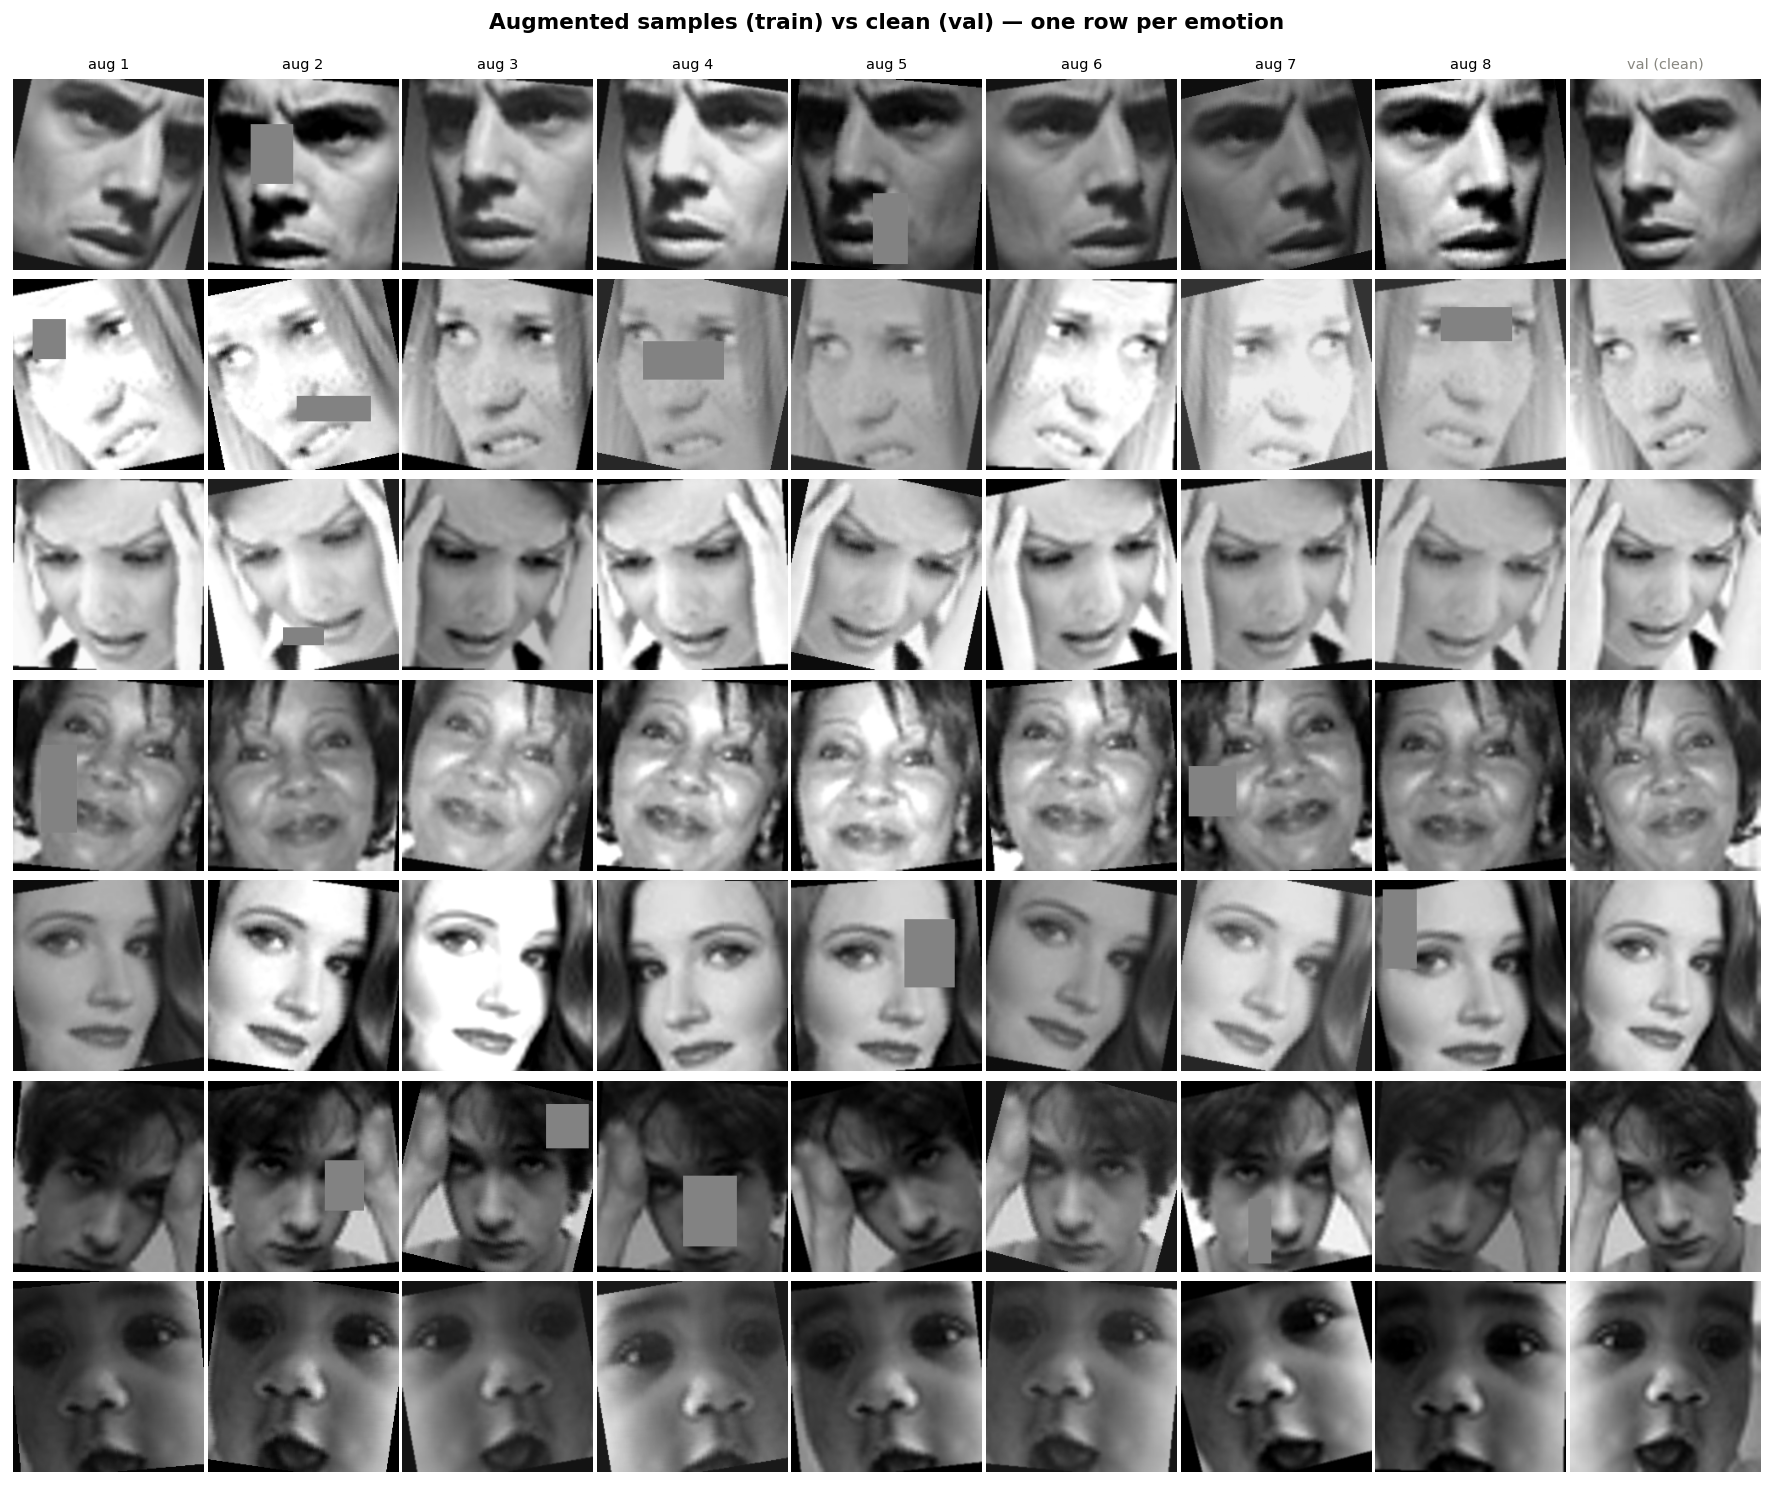

✓ Saved augmentation_grid.png


In [10]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """Reverse normalization for display."""
    mean = torch.tensor(DATASET_MEAN).view(3, 1, 1)
    std  = torch.tensor(DATASET_STD).view(3, 1, 1)
    img  = tensor * std + mean
    img  = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


PALETTE = {
    "angry": "#E24B4A", "disgust": "#639922", "fear": "#7F77DD",
    "happy": "#EF9F27", "neutral": "#888780", "sad": "#378ADD", "surprise": "#D4537E",
}

# Pick one image per emotion from train set (raw, no transform)
train_ds_raw = FERDataset(DATASET_ROOT, "train", transform=None)

# Group by label
by_class = {i: [] for i in range(NUM_CLASSES)}
for path, label in train_ds_raw.samples:
    by_class[label].append(path)

N_AUG = 8  # augmented versions per image
fig, axes = plt.subplots(NUM_CLASSES, N_AUG + 1,
                         figsize=((N_AUG + 1) * 1.5, NUM_CLASSES * 1.6))

for row, emotion in enumerate(EMOTIONS):
    idx    = LABEL2IDX[emotion]
    src    = random.choice(by_class[idx])
    pil_img = Image.open(src).convert("RGB")

    for col in range(N_AUG):
        aug = train_transform(pil_img)
        axes[row][col].imshow(denormalize(aug))
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(emotion, fontsize=9, fontweight="bold",
                                      color=PALETTE[emotion])

    # Final column: clean val transform
    clean = val_transform(pil_img)
    axes[row][N_AUG].imshow(denormalize(clean))
    axes[row][N_AUG].axis("off")
    if row == 0:
        axes[row][N_AUG].set_title("val (clean)", fontsize=8, color="#888780")

# Column headers for augmented cols
for col in range(N_AUG):
    axes[0][col].set_title(f"aug {col+1}", fontsize=8)

fig.suptitle("Augmented samples (train) vs clean (val) — one row per emotion",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(pad=0.2)
plt.savefig("eda_outputs/augmentation_grid.png", bbox_inches="tight")
plt.show()
print("✓ Saved augmentation_grid.png")


## 11. Saving Pipeline Configuration and Outputs

This final section saves the essential outputs generated during the data preparation phase for use in later stages of the project. The computed `class_weights` tensor is stored for use with `CrossEntropyLoss`, while the complete pipeline configuration is saved as a reusable configuration file. The saved configuration includes dataset information, label mappings, normalization parameters, image settings, and training statistics required by future phases such as model construction and training. Finally, a summary of the generated DataLoaders is displayed to verify the dataset sizes, batch counts, and sampling strategy used for each split. Saving these components improves reproducibility and allows subsequent phases to reload the same configuration without repeating preprocessing steps.

In [11]:
import pickle, torch

# Save class_weights tensor
torch.save(class_weights, "eda_outputs/class_weights.pt")
print("✓ Saved class_weights.pt")

# Save config dict that Phase 3 will import
phase2_config = {
    "DATASET_ROOT"    : str(DATASET_ROOT),
    "EMOTIONS"        : EMOTIONS,
    "NUM_CLASSES"     : NUM_CLASSES,
    "LABEL2IDX"       : LABEL2IDX,
    "IDX2LABEL"       : IDX2LABEL,
    "DATASET_MEAN"    : DATASET_MEAN,
    "DATASET_STD"     : DATASET_STD,
    "IMG_SIZE"        : IMG_SIZE,
    "BATCH_SIZE"      : BATCH_SIZE,
    "NUM_WORKERS"     : NUM_WORKERS,
    "TRAIN_COUNTS"    : TRAIN_COUNTS,
}
with open("eda_outputs/data_pipeline_config.pkl", "wb") as f:
    pickle.dump(phase2_config, f)
print("✓ Saved data_pipeline_config.pkl")

print("\n── Summary ───────────────────────────────────────────────────")
for split, loader in dataloaders.items():
    ds = loader.dataset
    print(f"  {split:>5} DataLoader — {len(ds):>6,} samples, "
          f"{len(loader):>4} batches, "
          f"sampler={'WeightedRandom' if split=='train' and USE_WEIGHTED_SAMPLER else 'default'}")
print(f"\n  class_weights : {class_weights.tolist()}")
print(f"  → Pass to: nn.CrossEntropyLoss(weight=class_weights.to(device))")


✓ Saved class_weights.pt
✓ Saved data_pipeline_config.pkl

── Summary ───────────────────────────────────────────────────
  train DataLoader — 24,406 samples,  381 batches, sampler=WeightedRandom
    val DataLoader —  4,303 samples,   68 batches, sampler=default
   test DataLoader —  7,178 samples,  113 batches, sampler=default

  class_weights : [1.026669979095459, 9.397767066955566, 1.0010254383087158, 0.5684936046600342, 0.8260059952735901, 0.8491406440734863, 1.293238639831543]
  → Pass to: nn.CrossEntropyLoss(weight=class_weights.to(device))
